## How are in-demand skills trending for Data Analyst?

#### Methodology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [1]:
# import library 
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

# load data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_INA = df[(df['job_country'] == 'Indonesia') & (df['job_title_short'] == 'Data Analyst')].copy()

In [3]:
df_DA_INA['job_posted_month_no'] = df_DA_INA['job_posted_date'].dt.month

In [4]:
df_DA_INA_explode = df_DA_INA.explode('job_skills')

In [5]:
df_DA_INA_pivot = df_DA_INA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_INA_pivot.loc['Total'] = df_DA_INA_pivot.sum()

df_DA_INA_pivot = df_DA_INA_pivot[df_DA_INA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_INA_pivot.drop('Total', inplace=True)

df_DA_INA_pivot

job_skills,sql,python,excel,tableau,r,power bi,sas,bigquery,spreadsheet,mysql,...,outlook,perl,plotly,express,puppet,couchbase,pytorch,confluence,rust,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,19,10,12,7,2,7,0,3,2,4,...,0,0,0,0,0,0,0,0,0,0
2,17,9,6,9,8,7,6,2,1,1,...,0,0,0,0,0,0,0,0,0,0
3,13,9,7,6,4,2,2,2,0,2,...,0,0,0,0,0,0,0,0,0,0
4,13,6,8,4,4,7,2,1,1,2,...,0,0,0,0,0,0,0,0,0,0
5,12,9,5,8,4,5,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
6,14,9,6,6,4,1,0,3,4,0,...,0,0,0,0,1,0,1,1,1,0
7,12,7,10,7,2,2,2,1,2,1,...,0,0,0,0,0,0,0,0,0,0
8,11,14,4,13,6,3,0,6,2,2,...,0,0,0,0,0,0,0,0,0,0
9,13,15,12,5,9,5,6,4,3,1,...,0,1,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month_no'>

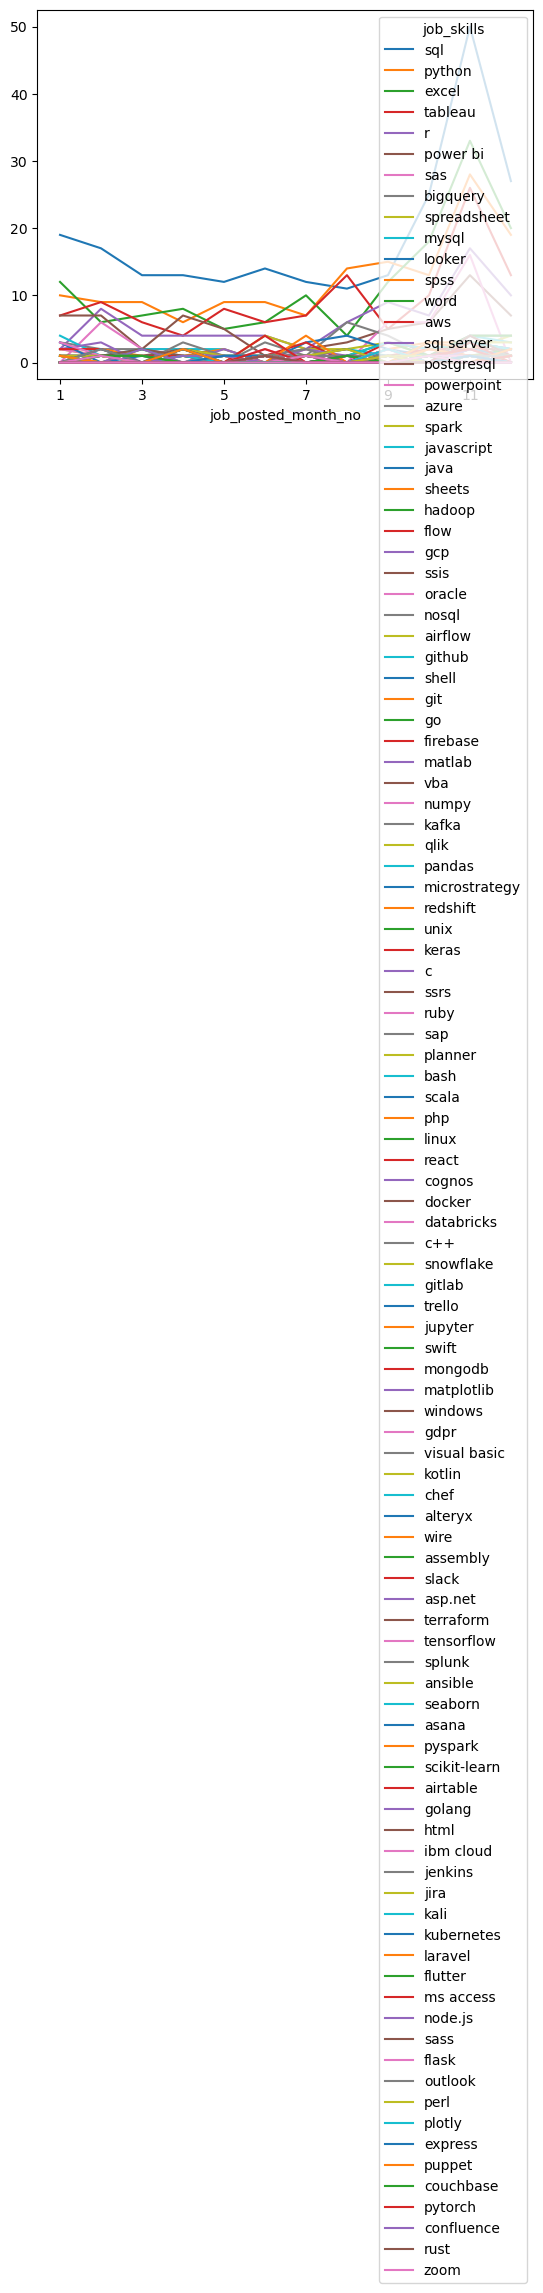

In [6]:
df_DA_INA_pivot.plot(kind='line')

In [ ]:
df_total = df_DA_INA.groupby('job_posted_month_no').size()

job_posted_month_no
1      35
2      25
3      21
4      20
5      25
6      22
7      25
8      32
9      34
10     61
11    106
12     55
dtype: int64

In [23]:
df_DA_INA_percent = df_DA_INA_pivot.div(df_total/100, axis=0)

df_DA_INA_percent

job_skills,sql,python,excel,tableau,r,power bi,sas,bigquery,spreadsheet,mysql,...,outlook,perl,plotly,express,puppet,couchbase,pytorch,confluence,rust,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,54.285714,28.571429,34.285714,20.000000,5.714286,20.000000,0.000000,8.571429,5.714286,11.428571,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,68.000000,36.000000,24.000000,36.000000,32.000000,28.000000,24.000000,8.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,61.904762,42.857143,33.333333,28.571429,19.047619,9.523810,9.523810,9.523810,0.000000,9.523810,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,65.000000,30.000000,40.000000,20.000000,20.000000,35.000000,10.000000,5.000000,5.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,48.000000,36.000000,20.000000,32.000000,16.000000,20.000000,0.000000,0.000000,0.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,63.636364,40.909091,27.272727,27.272727,18.181818,4.545455,0.000000,13.636364,18.181818,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.545455,0.000000,4.545455,4.545455,4.545455,0.000000
7,48.000000,28.000000,40.000000,28.000000,8.000000,8.000000,8.000000,4.000000,8.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,34.375000,43.750000,12.500000,40.625000,18.750000,9.375000,0.000000,18.750000,6.250000,6.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,38.235294,44.117647,35.294118,14.705882,26.470588,14.705882,17.647059,11.764706,8.823529,2.941176,...,0.000000,2.941176,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_DA_INA_percent = df_DA_INA_percent.reset_index()
df_DA_INA_percent['job_posted_month'] = df_DA_INA_percent['job_posted_month_no'].apply(lambda x : pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_INA_percent = df_DA_INA_percent.set_index('job_posted_month')
df_DA_INA_percent = df_DA_INA_percent.drop(columns='job_posted_month_no')

df_DA_INA_percent

job_skills,sql,python,excel,tableau,r,power bi,sas,bigquery,spreadsheet,mysql,...,outlook,perl,plotly,express,puppet,couchbase,pytorch,confluence,rust,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,54.285714,28.571429,34.285714,20.000000,5.714286,20.000000,0.000000,8.571429,5.714286,11.428571,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,68.000000,36.000000,24.000000,36.000000,32.000000,28.000000,24.000000,8.000000,4.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,61.904762,42.857143,33.333333,28.571429,19.047619,9.523810,9.523810,9.523810,0.000000,9.523810,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,65.000000,30.000000,40.000000,20.000000,20.000000,35.000000,10.000000,5.000000,5.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,48.000000,36.000000,20.000000,32.000000,16.000000,20.000000,0.000000,0.000000,0.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,63.636364,40.909091,27.272727,27.272727,18.181818,4.545455,0.000000,13.636364,18.181818,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.545455,0.000000,4.545455,4.545455,4.545455,0.000000
Jul,48.000000,28.000000,40.000000,28.000000,8.000000,8.000000,8.000000,4.000000,8.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,34.375000,43.750000,12.500000,40.625000,18.750000,9.375000,0.000000,18.750000,6.250000,6.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,38.235294,44.117647,35.294118,14.705882,26.470588,14.705882,17.647059,11.764706,8.823529,2.941176,...,0.000000,2.941176,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


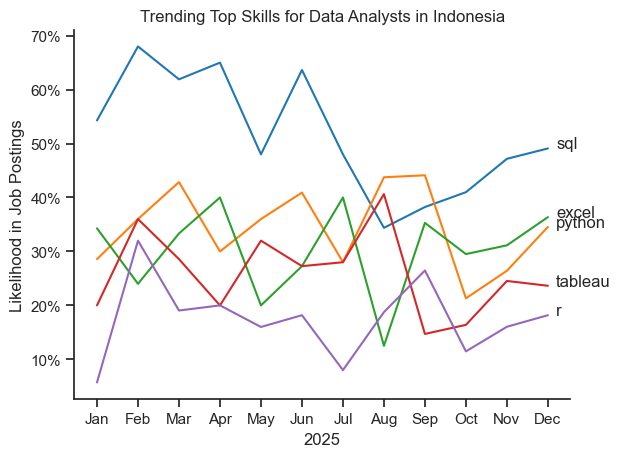

In [45]:
df_plot = df_DA_INA_percent.iloc[:, :5]

sns.lineplot(df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in Indonesia')
plt.ylabel('Likelihood in Job Postings')
plt.xlabel('2025')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])

plt.show()